# Inference with Flow Matching

In [104]:
import random

import numpy as np
import torch
import xarray as xr

import importlib.resources as resources
import yaml
import pathlib

import json
from abc import ABC, abstractmethod
from typing import Any
from collections.abc import Mapping

from torch.nn import Module
from torch import Tensor
from einops import rearrange
import math

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [105]:
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
DEVICE

device(type='cuda', index=0)

In [106]:
# Experiment choice: either 'historical' or 'historical_and_future'
experiment = 'historical'

# Number of samples to generate
n_samples = 1

# Forward-Euler timestepping params
n_steps = 10 # Number of time steps to simulate
alpha = 1 # Exponent for the time-stepping scheme

# Batch size for data loading
batch_size = 1

num_workers = 8

In [107]:
flow_matching_base_path = pathlib.Path('/gws/ssde/j25a/mmh_storage/ai4c_data/flow_matching/sa_hackathon/')
experiment_path = flow_matching_base_path / f'sa_{experiment}'

# Pre-trained model data
config_path = experiment_path / 'emulator.yaml'
model_path = experiment_path / 'model.pth'
predictor_transforms_path = experiment_path / 'predictor_transforms.json'
target_transforms_path = experiment_path / 'target_transforms.json'

# CORDEXBench input data
predictors_path = pathlib.Path('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/predictors/ACCESS-CM2_1961-1980_2080-2099.nc')
targets_path = pathlib.Path('/gws/nopw/j04/mohc_shared/cordexbench/SA_domain/train/Emulator_hist_future/target/pr_tasmax_ACCESS-CM2_1961-1980_2080-2099.nc')
static_fields_path = flow_matching_base_path / 'Static_fields.nc'

with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

targets: list[str] = list(config["targets"].keys())
print(f"Configuration:\n{config}")

Configuration:
{'predictors': {'u_850': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'u_700': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'u_500': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'v_850': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'v_700': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'v_500': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'q_850': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'q_700': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 'q_500': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 't_850': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 't_700': {'transforms': [{'name': 'normalisation', 'dims': ['time', 'lat', 'lon']}]}, 't_500': {'transforms':

In [108]:
# Outputs path - where model predictions are saved
output_path = pathlib.Path('/gws/nopw/j04/mohc_shared/users/jar212/cordexbench/flow_matching/outputs')
output_path.mkdir(parents=True, exist_ok=True)

In [109]:
class Transform(ABC):
    def __init__(self, **kwargs): ...

    @abstractmethod
    def fit(self, data: xr.DataArray) -> None:
        """Compute any statistics needed to parameterise the transform.

        Args:
            data: Data array to fit the transform on; typically the training data for a variable.
        """

    @abstractmethod
    def transform(self, data: xr.DataArray) -> xr.DataArray: ...

    @abstractmethod
    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray: ...

    @abstractmethod
    def state_dict(self) -> dict[str, Any]:
        """Return a dictionary capturing the state of the transform.

        Returns:
            A dictionary containing all parameters needed to re-instantiate the transform,
            including any statistics computed during `fit`.
        """

    @abstractmethod
    def load_state_dict(self, state: Mapping[str, Any]):
        """Load a previously saved transform state.

        Args:
            state: A mapping containing all parameters needed to re-instantiate the transform.
        """

class Log1pTransform(Transform):
    def fit(self, data: xr.DataArray) -> None:
        pass

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        if (data < -1).any():
            raise ValueError("Log1pTransform input contains NaNs or values < -1.")
        return np.log1p(data)

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        return np.expm1(data)

    def state_dict(self) -> dict[str, Any]:
        return {"name": "log1p"}

    def load_state_dict(self, state: Mapping[str, Any]):
        pass



class NormalisationTransform(Transform):
    """Z-score normalisation transform."""

    def __init__(self, dims: list[str], **kwargs):
        self.dims = dims  # Dimensions to compute mean and std over
        self.mean = None
        self.std = None

    def fit(self, data: xr.DataArray) -> None:
        """Compute mean and std over specified dimensions, ignoring NaNs."""
        self.mean = float(data.mean(dim=self.dims, skipna=True).compute())
        self.std = max(
            float(data.std(dim=self.dims, skipna=True).compute()), 1e-6
        )  # Avoid division by zero

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        return (data - self.mean) / self.std

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        return data * self.std + self.mean

    def state_dict(self) -> dict:
        return {"name": "normalisation", "dims": self.dims, "mean": self.mean, "std": self.std}

    def load_state_dict(self, state: dict):
        self.dims = state["dims"]
        self.mean = state["mean"]
        self.std = state["std"]


class ClipOutputsTransform(Transform):
    """Clip model outputs to a specified min and max value.

    Note that this transform is a no-op during the `transform` step, and is only applied during
    `inverse_transform`. It is useful when the model outputs may be outside a valid range, e.g.
    negative precipitation values after reversing a normalisation transform (when using a model
    trained in normalised space).

    In most cases, this transform should be placed at the *start* of the list of transforms for
    an output variable, so that it is the last transform applied during inverse_transform.
    """

    def __init__(self, min: float | None = None, max: float | None = None, **kwargs):
        """Initialise.

        Args:
            min: Minimum value to clip to. If None, no minimum clipping is applied.
            max: Maximum value to clip to. If None, no maximum clipping is applied.

        Raises:
            ValueError: If min is not less than max.
        """
        self.min = min
        self.max = max

        if self.min is not None and self.max is not None:
            if self.min >= self.max:
                raise ValueError(f"ClipOutputsTransform min {self.min} must be < max {self.max}.")

    def fit(self, data: xr.DataArray) -> None:
        pass

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        # No-op during transform. This transform is to clip model outputs only.
        return data

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        return np.clip(data, self.min, self.max)

    def state_dict(self) -> dict:
        return {"name": "clip_outputs", "min": self.min, "max": self.max}

    def load_state_dict(self, state: dict):
        self.min = state["min"]
        self.max = state["max"]


class ComposeTransform(Transform):
    """Compose several transforms together."""

    def __init__(self, transforms: list[Transform]):
        self.transforms = transforms

    def fit(self, data: xr.DataArray) -> None:
        for t in self.transforms:
            t.fit(data)
            data = t.transform(data)

    def transform(self, data: xr.DataArray) -> xr.DataArray:
        for t in self.transforms:
            data = t.transform(data)
        return data

    def inverse_transform(self, data: xr.DataArray | np.ndarray) -> xr.DataArray | np.ndarray:
        for t in reversed(self.transforms):
            data = t.inverse_transform(data)
        return data

    def state_dict(self) -> dict:
        return {
            "name": "compose",
            "transforms": [transform.state_dict() for transform in self.transforms],
        }

    def load_state_dict(self, state: dict):
        for transform, transform_state in zip(self.transforms, state["transforms"]):
            transform.load_state_dict(transform_state)


TRANSFORM_REGISTRY = {
    "log1p": Log1pTransform,
    "normalisation": NormalisationTransform,
    "clip_outputs": ClipOutputsTransform,
}
"""Mapping from transform names to classes."""



def _load_transform_from_state(state: dict) -> Transform:
    """Instantiate a transform from a state dictionary

    Args:
        state: Dictionary which captures state required to instantiate a Transformation,
            including any previously-computed statistics, e.g,
            ```
            {
                "name": "normalisation,
                "dims": ["time", "grid_latitude", "grid_longitude"],
                "mean: 0.74,
                "std": 0.93
            }
            ```

    Returns:
        Transform instance with loaded state.

    Raises:
        ValueError: If the transform name is not "compose" or not in the TRANSFORM_REGISTRY.
    """
    name = state["name"]

    if name == "compose":
        transforms = []
        for transform_state in state["transforms"]:
            transforms.append(_load_transform_from_state(transform_state))
        return ComposeTransform(transforms)

    elif name in TRANSFORM_REGISTRY:
        transform = TRANSFORM_REGISTRY[name](**state)
        transform.load_state_dict(state)
        return transform

    else:
        raise ValueError(f"Unknown transform: {name}")


def load_transforms(path: str) -> dict[str, Transform]:
    """Load transforms from a JSON file.

    Args:
        path: Full path to the JSON file containing the transforms.

    Returns:
        transform_map: Dictionary mapping from variable name to a Transform instance with loaded
            state.
    """
    with open(path) as fh:
        states = json.load(fh)

    transform_map: dict[str, dict[str, Transform]] = {}
    for group, group_states in states.items():
        transform_map[group] = {
            var_name: _load_transform_from_state(state) for var_name, state in group_states.items()
        }

    return transform_map

In [110]:
predictor_transforms = load_transforms(predictor_transforms_path)
target_transforms = load_transforms(target_transforms_path)
transforms: dict[str, dict[str, Transform]] = {
    "predictors": predictor_transforms["predictors"],
    "targets": target_transforms["targets"],
}

In [111]:
class CordexBenchDataset(torch.utils.data.Dataset):
    """Dataset for CordexBench."""

    def __init__(
        self,
        predictors_path: str,
        config: dict,
        transforms: dict[str, dict[str, Transform]],
        years: list[str],
        targets_path: str | None = None,
        static_fields_path: str | None = None,
    ):
        """
        Initialise.

        Args:
            predictors_path: Path to netcdf file containing predictor variables.
            config: Configuration dictionary.
            transforms: Mapping from group name to dictionary of variable name to Transform.
            years: List of year range strings (e.g., "1961-1970") or individual year strings
                (e.g., "2032") to include in the dataset.
            targets_path: Path to netcdf file containing target variables. If None, zero-tensor
                placeholders are returned for targets.
            static_fields_path: Path to netcdf file containing static fields. If None,
                no static fields are used.
        """
        self.transforms = transforms
        self.config = config

        self.predictors = list(config["predictors"].keys())
        self.targets = list(config["targets"].keys())
        if config["source"]["type"] == "coupled":
            self.source = list(config["source"]["variables"].keys())
            if len(self.source) != len(self.targets):
                raise ValueError(
                    f"Number of coupled variables ({len(self.source)}) must equal the number "
                    f"target variables ({len(self.targets)})."
                )
        else:
            self.source = []

        self.year_ranges = self._parse_years(years)

        predictors_ds = xr.open_dataset(predictors_path)
        self.predictors_ds = self._restrict_to_years(predictors_ds, self.year_ranges)

        self.targets_ds: xr.Dataset | None = None
        if targets_path is not None:
            targets_ds = xr.open_dataset(targets_path)
            self.targets_ds = self._restrict_to_years(targets_ds, self.year_ranges)

        self.orography: torch.Tensor | None = None
        if static_fields_path is not None:
            static_ds = xr.open_dataset(static_fields_path)
            orography = static_ds["orog"].values
            # Min-max normalisation
            orography = (orography - orography.min()) / (orography.max() - orography.min())
            self.orography = torch.tensor(orography, dtype=torch.float32).unsqueeze(
                0
            )  # shape (1, lat, lon)

        self.length = self.predictors_ds.dims["time"]
        #logger.info(f"CordexBenchDataset initialized with {self.length} samples.")

    def __len__(self) -> int:
        return self.length

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """Return a sample from the dataset.

        Transforms are applied. Predictors are upscaled to match target spatial
        resolution (lat, lon).

        Args:
            idx: Index of the sample to retrieve.

        Returns:
            predictors: Tensor of conditioning variables, shape (no. conditioning variables, lat, lon)
            targets: Tensor of target variables, shape (no. targets, lat, lon)
            source: If config source type is "coupled", returns a tensor of coupled source
                variables, shape (no. coupled variables, lat, lon). Otherwise, returns an empty,
                placeholder tensor of the same shape as targets.
        """
        # Load predictors

        predictors_sample = self.predictors_ds[self.predictors + self.source].isel(time=idx)
        predictors = self._get_group_tensor(predictors_sample, self.predictors, "predictors")

        # Upscale predictors to match target spatial resolution (16x16 -> 128x128)
        predictors = torch.nn.functional.interpolate(
            predictors.unsqueeze(
                0
            ),  # interpolate expects batch dimension, so we temporarily add one
            scale_factor=8,
            mode="bilinear",
            align_corners=False,
        ).squeeze(0)  # shape back to (no. conditioning variables, lat, lon)

        # Append orography field to predictors if available
        if self.orography is not None:
            predictors = torch.cat([predictors, self.orography], dim=0)

        # Load targets

        if self.targets_ds is None:
            # Return zero-tensor placeholders for targets
            targets = torch.zeros(
                (len(self.targets), predictors.shape[1], predictors.shape[2]), dtype=torch.float32
            )
        else:
            targets_sample = self.targets_ds[self.targets].isel(time=idx)
            targets = self._get_group_tensor(targets_sample, self.targets, "targets")

        # Load source variables if applicable

        source = (
            self._get_group_tensor(predictors_sample, self.source, "source")
            if self.source
            else torch.empty_like(targets)
        )

        return predictors, targets, source

    def _get_group_tensor(
        self, sample: xr.Dataset, variables: list[str], name: str
    ) -> torch.Tensor:
        """Get a tensor for a group of variables.

        Args:
            sample: Dataset sample containing the variables.
            variables: List of variable names to retrieve.
            name: Name of the group, one of "predictors", "targets" or "source".

        Returns:
            group_tensor: Tensor containing the transformed values of the specified variables.
                Shape (no. variables, lat, lon).
        """
        tensors: list[torch.Tensor] = []

        for var in variables:
            # Force load the data from disk into memory explicitly.
            # This ensures we get an efficient slab read from the NetCDF file
            # before any arithmetic transforms construct a complex graph.
            data = sample[var].load()

            transformed = torch.tensor(
                self.transforms[name][var].transform(data).values, dtype=torch.float32
            )
            tensors.append(transformed)

        group_tensor = torch.stack(tensors)

        return group_tensor

    def _restrict_to_years(self, ds: xr.Dataset, year_ranges: list[tuple[int, int]]) -> xr.Dataset:
        """Restrict dataset to the specified year range(s)."""
        masks = []
        years = ds["time"].dt.year

        for start, end in year_ranges:
            masks.append((years >= start) & (years <= end))

        combined_mask = masks[0]
        for mask in masks[1:]:
            combined_mask = combined_mask | mask

        return ds.sel(time=combined_mask)

    def _parse_years(self, years: list[str]) -> list[tuple[int, int]]:
        """Parse year ranges or individual years from strings to tuples of integers.

        Args:
            years: List of year range strings (e.g., "1961-1970") or individual year strings
                (e.g., "2032").

        Returns:
            year_ranges: List of tuples of integers representing the year ranges,
                e.g. [(1961, 1970), (2032, 2032)].
        """
        year_ranges = []
        for year_spec in years:
            if "-" in year_spec:
                # Handle a range, e.g., "1961-1970"
                start_year_str, end_year_str = year_spec.split("-")
                start_year = int(start_year_str)
                end_year = int(end_year_str)
            else:
                # Handle a single year, e.g., "2032"
                single_year = int(year_spec)
                start_year = single_year
                end_year = single_year

            year_ranges.append((start_year, end_year))
        return year_ranges

In [112]:
test_dataset = CordexBenchDataset(
        predictors_path=predictors_path,
        config=config,
        transforms=transforms,
        years=config["test"]["years"],
        targets_path=targets_path,
        static_fields_path=static_fields_path,
    )

/tmp/ipykernel_180/893139100.py:62: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  self.length = self.predictors_ds.dims["time"]


In [113]:
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers
)

In [114]:
num_conditioning_variables = len(config["predictors"]) + (
    1 if static_fields_path is not None else 0
)
print(num_conditioning_variables)

16


In [115]:
class FourierEmbedding(Module):
    """Fourier Embedding.

    FE(t) = [sin(2 * pi * t * w_1), cos(2 * pi * t * w_1), ..., sin(2 * pi * t * w_d/2), cos(2 * pi * t * w_d/2)] * sqrt(2),
    where w_i are the weights of the Fourier embedding and t is a scalar time in [0, 1].
    """

    def __init__(self, dim: int, learnable: bool = False):
        """Initialise.

        Args:
            dim: Dimension of the output embedding. Must be even.
            learnable: If True, the weights will be learnable parameters. If False, they
                will be fixed random values drawn from a normal distribution.
        """
        super().__init__()
        assert dim % 2 == 0
        half_dim = dim // 2
        self.weights = torch.nn.Parameter(torch.randn(half_dim), requires_grad=learnable)

    def forward(self, t: Tensor) -> Tensor:
        """Embed time tensor using fourier embedding.

        Args:
            t: Times between 0 and 1, shape (batch_size, 1)

        Returns:
            Fourier embedding, shape (batch_size, dim)
        """
        freqs = t * rearrange(self.weights, "half_dim -> 1 half_dim") * 2 * math.pi
        return torch.cat((freqs.sin(), freqs.cos()), dim=-1) * math.sqrt(2)


class Conv2d(torch.nn.Module):
    """Convolution layer, with optional downsampling or upsampling."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int,
        bias: bool = True,
        upsample: bool = False,
        downsample: bool = False,
        resample_filter: list[int] = [1, 1],
    ):
        """Inititalise block.

        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            kernel_size: Kernel size of convolution layer. If 0, no convolution is applied.
            bias: If True, add a bias term to the convolution layer.
            upsample: If True, upsample by a factor of 2.
            downsample: If True, downsample by a factor of 2.
            resample_filter: 1D kernel/filter for up/downsampling. Defaults to [1, 1], which is
                equivalent to average pooling.
        """
        assert not (upsample and downsample)
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.upsample = upsample
        self.downsample = downsample

        self.conv = (
            torch.nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size,
                padding=kernel_size // 2 if kernel_size > 0 else 0,
                bias=bias,
            )
            if kernel_size > 0
            else None
        )

        f = torch.as_tensor(resample_filter, dtype=torch.float32)
        f = f.ger(f).unsqueeze(0).unsqueeze(1) / f.sum().square()
        self.register_buffer("resample_filter", f if upsample or downsample else None)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Upsampling / downsampling
        f = self.resample_filter.to(x.dtype) if self.resample_filter is not None else None
        f_pad = (f.shape[-1] - 1) // 2 if f is not None else 0

        if self.upsample:
            x = torch.nn.functional.conv_transpose2d(
                x,
                f.mul(4).tile([self.in_channels, 1, 1, 1]),
                groups=self.in_channels,
                stride=2,
                padding=f_pad,
            )
        elif self.downsample:
            x = torch.nn.functional.conv2d(
                x,
                f.tile([self.in_channels, 1, 1, 1]),
                groups=self.in_channels,
                stride=2,
                padding=f_pad,
            )

        if self.conv is not None:
            x = self.conv(x)

        return x


class Encoder(Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        emb_channels: int,
        downsample: bool = False,
        adaptive_scale: bool = True,
        resample_filter: list[int] = [1, 1],
        attention: bool = False,
        channels_per_head: int = 64,
        dropout: float = 0.0,
    ):
        """Initialise encoder block.

        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            emb_channels: Number of channels in the time embedding.
            downsample: If True, downsample by a factor of 2.
            adaptive_scale: If True, apply FiLM conditioning (scale and shift the input features).
                If False, apply additive conditioning (add the embedding to the input features).
            resample_filter: 1D kernel/filter for downsampling. Defaults to [1, 1], which is
                equivalent to average pooling.
            attention: If True, apply attention mechanism.
            channels_per_head: Number of channels per attention head, if attention is True.
            dropout: Dropout rate applied after the first convolution layer.
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.adaptive_scale = adaptive_scale

        # Affine transformation applied to time embedding
        self.affine = torch.nn.Linear(
            in_features=emb_channels,
            out_features=out_channels * (2 if adaptive_scale else 1),
            bias=True,
        )

        layers_pre_modulation: list[torch.nn.Module] = [
            torch.nn.GroupNorm(num_groups=32, num_channels=in_channels),
            torch.nn.SiLU(),
            Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                bias=True,
                downsample=downsample,
                resample_filter=resample_filter,
            ),
            torch.nn.GroupNorm(num_groups=32, num_channels=out_channels),
        ]
        self.layers_pre_modulation = torch.nn.Sequential(*layers_pre_modulation)

        layers_post_modulation: list[torch.nn.Module] = [
            torch.nn.SiLU(),
            torch.nn.Dropout(p=dropout),
            Conv2d(out_channels, out_channels, kernel_size=3, bias=True, downsample=False),
        ]
        self.layers_post_modulation = torch.nn.Sequential(*layers_post_modulation)

        # Skip connection
        if out_channels != in_channels or downsample:
            # Use 1x1 convolution if we need to change the number of channels.
            # Otherwise (if we're just downsampling), there is no convolution applied.
            kernel = 1 if out_channels != in_channels else 0
            self.skip = Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel,
                downsample=downsample,
                resample_filter=resample_filter,
            )
        else:
            # No need to modify the input if the number of channels is constant and no downsampling is applied.
            self.skip = torch.nn.Identity()

        # Multi-head self-attention
        self.attention = attention
        if self.attention:
            if out_channels % channels_per_head != 0:
                raise ValueError(
                    f"out_channels ({out_channels}) must be divisible by channels_per_head ({channels_per_head})"
                )
            self.num_heads = out_channels // channels_per_head
            self.norm2 = torch.nn.GroupNorm(num_groups=32, num_channels=out_channels)
            self.qkv = Conv2d(
                in_channels=out_channels, out_channels=out_channels * 3, kernel_size=1
            )
            self.proj = Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=1)

    def forward(self, x: Tensor, emb: Tensor) -> Tensor:
        """Forward pass.

        Args:
            x: Input tensor, shape (batch_size, in_channels, height, width)
            emb: Time embedding, shape (batch_size, emb_channels)

        Returns:
            x: Output tensor, shape (batch_size, out_channels, height', width'), where height' and
                width' depend on whether downsampling was applied (will be half the input size if downsample=True).
        """
        orig = x

        x = self.layers_pre_modulation(x)

        emb = rearrange(self.affine(emb), "bs c -> bs c 1 1")
        if self.adaptive_scale:
            # FiLM conditioning: scale and shift the input features
            scale, shift = torch.chunk(emb, 2, dim=1)
            x = x * (1 + scale) + shift  # identity if scale and shift are zero
        else:
            # Additive conditioning: add the embedding to the input features
            x = x + emb

        x = self.layers_post_modulation(x)
        x = self.skip(orig) + x

        if self.attention:
            q, k, v = (
                self.qkv(self.norm2(x))
                .reshape(x.shape[0] * self.num_heads, x.shape[1] // self.num_heads, 3, -1)
                .unbind(2)
            )

            scale = 1 / math.sqrt(k.size(1))
            w = torch.einsum("ncq,nck->nqk", q, k).mul_(scale)
            w = w.to(dtype=torch.float32).softmax(dim=2).to(dtype=q.dtype)
            a = torch.einsum("nqk,nck->ncq", w, v)

            x = self.proj(a.reshape(*x.shape)).add_(x)

        return x


class Decoder(Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        emb_channels: int,
        upsample: bool = False,
        adaptive_scale: bool = True,
        resample_filter: list[int] = [1, 1],
        attention: bool = False,
        channels_per_head: int = 64,
        dropout: float = 0.0,
    ):
        """Initialise decoder block.

        Args:
            in_channels: Number of input channels.
            out_channels: Number of output channels.
            emb_channels: Number of channels in the time embedding.
            upsample: If True, upsample by a factor of 2.
            adaptive_scale: If True, apply FiLM conditioning (scale and shift the input features).
                If False, apply additive conditioning (add the embedding to the input features).
            resample_filter: 1D kernel/filter for upsampling.
            attention: If True, apply attention mechanism.
            channels_per_head: Number of channels per attention head, if attention is True.
            dropout: Dropout rate applied after the first convolution layer.
        """
        super().__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.adaptive_scale = adaptive_scale

        # Affine transformation applied to time embedding
        self.affine = torch.nn.Linear(
            in_features=emb_channels,
            out_features=out_channels * (2 if adaptive_scale else 1),
            bias=True,
        )

        layers_pre_modulation: list[torch.nn.Module] = [
            torch.nn.GroupNorm(num_groups=32, num_channels=in_channels),
            torch.nn.SiLU(),
            Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                bias=True,
                upsample=upsample,
                resample_filter=resample_filter,
            ),
            torch.nn.GroupNorm(num_groups=32, num_channels=out_channels),
        ]
        self.layers_pre_modulation = torch.nn.Sequential(*layers_pre_modulation)

        layers_post_modulation: list[torch.nn.Module] = [
            torch.nn.SiLU(),
            torch.nn.Dropout(p=dropout),
            Conv2d(out_channels, out_channels, kernel_size=3, bias=True, upsample=False),
        ]
        self.layers_post_modulation = torch.nn.Sequential(*layers_post_modulation)

        # Skip connection
        if out_channels != in_channels or upsample:
            # Use 1x1 convolution if we need to change the number of channels.
            # Otherwise (if we're just upsampling), there is no convolution applied.
            kernel = 1 if out_channels != in_channels else 0
            self.skip = Conv2d(
                in_channels,
                out_channels,
                kernel_size=kernel,
                upsample=upsample,
                resample_filter=resample_filter,
            )
        else:
            # No need to modify the input if the number of channels is constant and no upsampling is applied.
            self.skip = torch.nn.Identity()

        # Multi-head self-attention
        self.attention = attention
        if self.attention:
            if out_channels % channels_per_head != 0:
                raise ValueError(
                    f"out_channels ({out_channels}) must be divisible by channels_per_head ({channels_per_head})"
                )
            self.num_heads = out_channels // channels_per_head
            self.norm2 = torch.nn.GroupNorm(num_groups=32, num_channels=out_channels)
            self.qkv = Conv2d(
                in_channels=out_channels, out_channels=out_channels * 3, kernel_size=1
            )
            self.proj = Conv2d(in_channels=out_channels, out_channels=out_channels, kernel_size=1)

    def forward(self, x: Tensor, emb: Tensor) -> Tensor:
        """Forward pass.

        Args:
            x: Input tensor, shape (batch_size, in_channels, height, width)
            emb: Time embedding, shape (batch_size, emb_channels)

        Returns:
            x: Output tensor, shape (batch_size, out_channels, height', width'), where height' and
                width' depend on whether upsampling was applied (will be double the input size if upsample=True).
        """
        orig = x

        x = self.layers_pre_modulation(x)

        emb = rearrange(self.affine(emb), "bs c -> bs c 1 1")
        if self.adaptive_scale:
            # FiLM conditioning: scale and shift the input features
            scale, shift = torch.chunk(emb, 2, dim=1)
            x = x * (1 + scale) + shift  # identity if scale and shift are zero
        else:
            # Additive conditioning: add the embedding to the input features
            x = x + emb

        x = self.layers_post_modulation(x)
        x = self.skip(orig) + x

        if self.attention:
            q, k, v = (
                self.qkv(self.norm2(x))
                .reshape(x.shape[0] * self.num_heads, x.shape[1] // self.num_heads, 3, -1)
                .unbind(2)
            )

            scale = 1 / math.sqrt(k.size(1))
            w = torch.einsum("ncq,nck->nqk", q, k).mul_(scale)
            w = w.to(dtype=torch.float32).softmax(dim=2).to(dtype=q.dtype)
            a = torch.einsum("nqk,nck->ncq", w, v)

            x = self.proj(a.reshape(*x.shape)).add_(x)

        return x


class ADM(Module):
    def __init__(
        self,
        num_conditioning_variables: int,
        num_target_variables: int,
        img_resolution: int = 64,
        model_channels: int = 192,
        channel_mult: list[int] = [1, 2, 3, 4],
        channel_mult_emb: int = 4,
        num_residual_blocks: int = 3,
        attention_resolutions: list[int] = [16, 8],
        dropout: float = 0.1,
    ):
        """
        Args:
            num_conditioning_variables: Number of conditioning variables.
            img_resolution: Resolution at input and output.
            model_channels: Base mutiplier for the number of channels.
            channel_mult: Per-resolution multipliers for the number of channels.
            channel_mult_emb: Multiplier for the dimensionality of the embedding vector.
            num_residual_blocks: Number of residual blocks per resolution.
            attention_resolutions: List of resolutions with self-attention.
            dropout: Dropout rate.
        """
        super().__init__()

        # The conditioning variables are concatenated with x_t (which has num_target_variables
        # channels).
        self.num_variables = num_conditioning_variables + num_target_variables
        self.num_target_variables = num_target_variables

        # Embedding
        emb_channels = model_channels * channel_mult_emb
        embedding_layers: list[torch.nn.ModuleDict] = [
            FourierEmbedding(dim=model_channels),
            torch.nn.Linear(in_features=model_channels, out_features=emb_channels, bias=True),
            torch.nn.SiLU(),
            torch.nn.Linear(in_features=emb_channels, out_features=emb_channels, bias=True),
            torch.nn.SiLU(),
        ]
        self.embedding = torch.nn.Sequential(*embedding_layers)

        # Encoder
        self.enc = torch.nn.ModuleDict()
        for level, mult in enumerate(channel_mult):
            res = img_resolution // (2**level)
            if level == 0:
                in_ch = self.num_variables
                out_ch = model_channels * mult
                self.enc[f"{res}x{res}_conv"] = Conv2d(
                    in_channels=in_ch, out_channels=out_ch, kernel_size=3
                )
            else:
                self.enc[f"{res}x{res}_down"] = Encoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    downsample=True,
                    attention=False,
                    dropout=dropout,
                )

            for idx in range(num_residual_blocks):
                in_ch = out_ch
                out_ch = model_channels * mult
                self.enc[f"{res}x{res}_block{idx}"] = Encoder(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    downsample=False,
                    attention=(res in attention_resolutions),
                    dropout=dropout,
                )
        skip_num_channels = [block.out_channels for block in self.enc.values()]

        # Decoder
        self.dec = torch.nn.ModuleDict()
        for level, mult in reversed(list(enumerate(channel_mult))):
            res = img_resolution // (2**level)
            if level == len(channel_mult) - 1:
                self.dec[f"{res}x{res}_mid1"] = Decoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    attention=True,
                    dropout=dropout,
                )
                self.dec[f"{res}x{res}_mid2"] = Decoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    attention=False,
                    dropout=dropout,
                )
            else:
                self.dec[f"{res}x{res}_up"] = Decoder(
                    in_channels=out_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    upsample=True,
                    attention=False,
                    dropout=dropout,
                )

            for idx in range(num_residual_blocks + 1):
                in_ch = out_ch + skip_num_channels.pop()
                out_ch = model_channels * mult
                self.dec[f"{res}x{res}_block{idx}"] = Decoder(
                    in_channels=in_ch,
                    out_channels=out_ch,
                    emb_channels=emb_channels,
                    upsample=False,
                    attention=(res in attention_resolutions),
                    dropout=dropout,
                )

        # Final output block
        self.out_block = torch.nn.Sequential(
            torch.nn.GroupNorm(num_groups=32, num_channels=out_ch),
            torch.nn.SiLU(),
            Conv2d(
                in_channels=out_ch, out_channels=self.num_target_variables, kernel_size=3, bias=True
            ),
        )

    def forward(self, x_t: Tensor, t: Tensor, conditioning: Tensor) -> Tensor:
        """Forward pass.

        Args:
            x_t: Samples from probability path, shape (batch_size, num_target_variables, height, width)
            t: Times between [0, 1], shape (batch_size, 1)
            conditioning: Conditioning variables, shape (batch_size, num_conditioning_variables, height, width)

        Returns:
            x: Velocity estimates, shape (batch_size, num_target_variables, height, width)
        """
        emb = self.embedding(t)  # shape (bs, emb_channels)

        x = torch.concat((x_t, conditioning), dim=1)

        # Encoder
        skips: torch.Tensor = []
        for block in self.enc.values():
            x = block(x, emb) if isinstance(block, Encoder) else block(x)
            skips.append(x)

        # Decoder
        for block in self.dec.values():
            if x.shape[1] != block.in_channels:
                x = torch.cat((x, skips.pop()), dim=1)
            x = block(x, emb)

        x = self.out_block(x)
        return x

In [116]:
model = ADM(
    num_conditioning_variables=num_conditioning_variables,
    num_target_variables=len(config["targets"]),
    **config["model"],
).to(DEVICE)

In [117]:
state_dict = torch.load(model_path, map_location=DEVICE)

state_dict = {
    k.replace("_orig_mod.", ""): v
    for k, v in state_dict.items()
}

model.load_state_dict(state_dict)

<All keys matched successfully>

In [118]:
class DistributionSampler:
    """Sample from a distribution."""

    def __init__(self, config: dict, device: torch.device):
        """Initialise sampler.

        Args:
            config: Configuration dictionary containing source type and parameters.
            device: Device to perform computations on (e.g., 'cpu' or 'cuda').

        Raises:
            ValueError: If the source type is not 'gaussian' or 'gamma'.
        """
        self.device = device
        src_type = config["source"]["type"].lower()

        if src_type == "gaussian":
            self.mean = config["source"]["mean"]
            self.std = config["source"]["std"]
            self.sample_fn = lambda shape: torch.normal(
                self.mean, self.std, size=shape, device=device
            )
        elif src_type == "gamma":
            shape = config["source"]["shape"]  # also known as alpha or concentration
            scale = config["source"]["scale"]  # also known as theta, equal to 1/rate
            self.dist = torch.distributions.Gamma(concentration=shape, rate=1.0 / scale)
            self.sample_fn = lambda shape: self.dist.sample(shape).to(device)
        else:
            raise ValueError(f"Unsupported source type: {src_type}")

    def sample(self, shape: tuple) -> torch.Tensor:
        """Returns a sample from the distribution.

        Args:
            shape: The shape of the sample to draw.

        Returns:
            Tensor of shape `shape` sampled from the distribution.
        """
        return self.sample_fn(shape)

In [120]:
source_sampler = DistributionSampler(config, DEVICE)


In [121]:
class Solver(ABC):
    def __init__(self, n_steps: int, alpha: float, model: torch.nn.Module, device: torch.device):
        """Initialise.

        Args:
            n_steps: Number of steps.
            alpha: Exponent for the time-stepping scheme. If alpha=1, then the time steps
                are uniformly spaced between 0 and 1 (constant step size). If alpha>1, then the
                step size is smaller near t=1 (the data/target side) and larger near t=0 (the
                noise/source side).
            model: Neural network model representing the velocity/vector field.
            device: Device
        """
        self.n_steps = n_steps
        self.alpha = alpha
        self.device = device
        self.model = model
        self.time_steps = (
            1 - (1 - torch.tensor(range(self.n_steps + 1)) / self.n_steps) ** self.alpha
        )  # shape (n_steps + 1, )
        self.step_sizes = self.time_steps[1:] - self.time_steps[:-1]  # shape (n_steps, )

    def simulate_ode(self, x_0: torch.Tensor, conditioning: torch.Tensor) -> torch.Tensor:
        """Simulate the ODE.

        Args:
            x_0: Tensor of shape (batch_size, num_target_variables, height, width)
            conditioning: Conditioning variables,
                shape (batch_size, num_conditioning_variables, height, width)

        Returns:
            x_1: Tensor of shape (batch_size, num_target_variables, height, width)
        """
        x_current = x_0.to(self.device)

        for idx, step_size in enumerate(self.step_sizes):
            t_current = self.time_steps[idx].item()
            t_current = torch.full(
                (x_current.shape[0], 1), t_current, device=self.device
            )  # shape (batch_size, 1)
            x_current = self.step(x_current, t_current, conditioning, step_size.item())

        return x_current

    @abstractmethod
    def step(
        self,
        x_current: torch.Tensor,
        t_current: torch.Tensor,
        conditioning: torch.Tensor,
        step_size: float,
    ) -> torch.Tensor:
        """Take a single step of the ODE solver.

        Args:
            x_current: Current state, shape (batch_size, num_target_variables, height, width)
            t_current: Current time between 0 and 1, shape (batch_size, 1)
            conditioning: Conditioning variables,
                shape (batch_size, num_conditioning_variables, height, width)
            step_size: Step size for this step.

        Returns:
            x_next: Next state, shape (batch_size, num_target_variables, height, width
        """
        pass


class EulerSolver(Solver):
    def step(
        self,
        x_current: torch.Tensor,
        t_current: torch.Tensor,
        conditioning: torch.Tensor,
        step_size: float,
    ) -> torch.Tensor:
        x_next = x_current + step_size * self.model(x_current, t_current, conditioning)
        return x_next


In [122]:
solver = EulerSolver(n_steps=n_steps, alpha=alpha, model=model, device=DEVICE)

In [123]:
prediction_batches: list[torch.Tensor] = []
for batch in test_dataloader:
    #logger.info(f"Generating {n_samples} samples for batch of size {batch[0].shape[0]}")

    conditioning, _, _ = batch

    samples = []
    for _ in range(n_samples):
        # Resample source for each sample
        x_0 = source_sampler.sample(
            (
                conditioning.shape[0],
                len(config["targets"]),
                conditioning.shape[2],
                conditioning.shape[3],
            )
        )  # shape (batch_size, num_target_variables, lat, lon)

        conditioning = conditioning.to(DEVICE)
        x_0 = x_0.to(DEVICE)

        model.eval()
        with torch.no_grad():
            x_1 = solver.simulate_ode(
                x_0=x_0, conditioning=conditioning
            )  # shape (batch_size, num_target_variables, lat, lon)
            samples.append(x_1.cpu())

    samples_tensor = torch.stack(
        samples, dim=0
    )  # shape (n_samples, batch_size, num_target_variables, lat, lon)
    prediction_batches.append(samples_tensor)

predictions = torch.cat(
    prediction_batches, dim=1
).numpy()  # shape (n_samples, time, num_target_variables, lat, lon)


In [124]:
data_vars: dict[str, xr.DataArray] = {}
for idx, target in enumerate(targets):
    # Inverse any transforms applied
   # logger.info(f"Applying inverse transform to target variable '{target}'")
    target_transform = transforms["targets"][target]
    predictions[:, :, idx, :, :] = target_transform.inverse_transform(
        predictions[:, :, idx, :, :]
    )

    # Propogate relevant attributes from the target variable
    target_attrs = test_dataset.targets_ds[target].attrs
    attrs = {"grid_mapping": "rotated_latitude_longitude"}
    for key in ["units", "standard_name"]:
        if key in target_attrs:
            attrs[key] = target_attrs[key]

    data_vars[f"pred_{target}"] = (
        ("sample", "input", "time", "grid_latitude", "grid_longitude"),
        np.expand_dims(
            predictions[:, :, idx, :, :], axis=1
        ),  # expand_dims adds 'dummy' input axis
        attrs,
    )

    data_vars[f"target_{target}"] = (
        ("input", "time", "grid_latitude", "grid_longitude"),
        np.expand_dims(test_dataset.targets_ds[target].data, axis=0),
        attrs,
    )

In [125]:
ds = xr.Dataset(
    data_vars=data_vars,
    coords={
        "sample": np.arange(n_samples),
        "input": [experiment],
        "time": test_dataset.predictors_ds["time"].data,
        "lat": test_dataset.predictors_ds["lat"].data,
        "lon": test_dataset.predictors_ds["lon"].data,
    },
    attrs={
        "solver_type": 'euler',
        "n_steps": n_steps,
        "alpha": alpha,
    },
)

output_file = f"{output_path}/predictions.nc"
ds.to_netcdf(output_file, format="NETCDF4", engine="netcdf4")
#logger.info(f"Predictions saved to {output_file}")

In [126]:
print(ds)

<xarray.Dataset> Size: 287MB
Dimensions:    (sample: 1, input: 1, time: 1460, grid_latitude: 128,
                grid_longitude: 128, lat: 16, lon: 16)
Coordinates:
  * sample     (sample) int64 8B 0
  * input      (input) <U10 40B 'historical'
  * time       (time) datetime64[ns] 12kB 1979-01-01T12:00:00 ... 2099-12-31T...
  * lat        (lat) float64 128B -40.0 -38.0 -36.0 -34.0 ... -14.0 -12.0 -10.0
  * lon        (lon) float64 128B 11.0 13.0 15.0 17.0 ... 35.0 37.0 39.0 41.0
Dimensions without coordinates: grid_latitude, grid_longitude
Data variables:
    pred_pr    (sample, input, time, grid_latitude, grid_longitude) float32 96MB ...
    target_pr  (input, time, grid_latitude, grid_longitude) float64 191MB 0.2...
Attributes:
    solver_type:  euler
    n_steps:      10
    alpha:        1


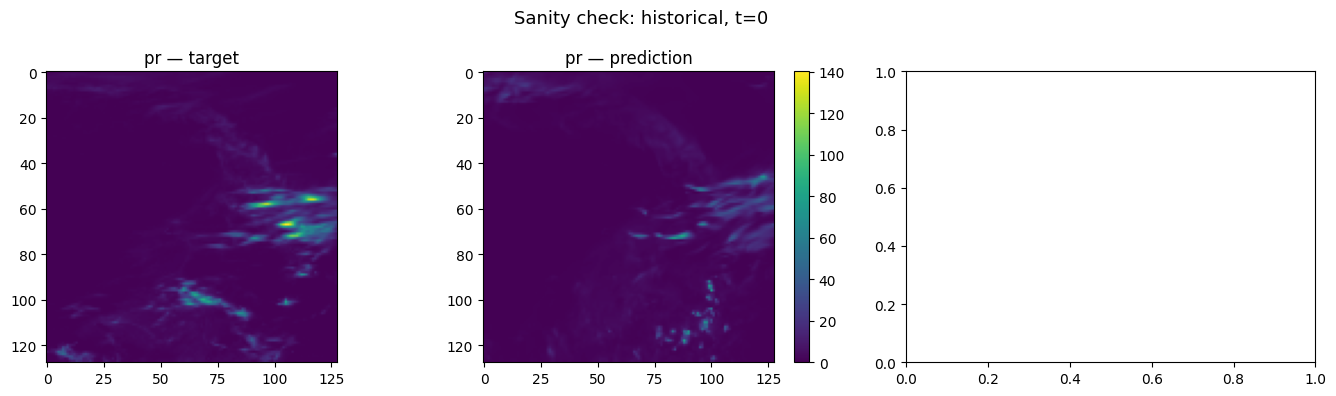

In [131]:
# Quick sanity check — plot the first prediction vs. target for each target variable
n_targets = len(targets)
fig, axes = plt.subplots(n_targets, 3, figsize=(14, 4 * n_targets))
if n_targets == 1:
    axes = axes[np.newaxis, :]  # ensure 2D indexing works for single target

for i, var in enumerate(targets):
    pred  = ds[f'pred_{var}'].isel(sample=0, input=0, time=1).values
    truth = ds[f'target_{var}'].isel(input=0, time=1).values

    vmin = min(pred.min(), truth.min())
    vmax = max(pred.max(), truth.max())

    axes[i, 0].imshow(truth, vmin=vmin, vmax=vmax)
    axes[i, 0].set_title(f"{var} — target")

    im = axes[i, 1].imshow(pred, vmin=vmin, vmax=vmax)
    axes[i, 1].set_title(f"{var} — prediction")
    plt.colorbar(im, ax=axes[i, 1])

fig.suptitle(f"Sanity check: {experiment}, t=0", fontsize=13)
plt.tight_layout()
plt.show()